In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys
from pathlib import Path
from ccpfn import CEPOEstimator 

# Import synthetic data
sys.path.append("..")
from benchmarks.scenarios import ADMIT

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Example: Running CCPFN

In this example, we demonstrate how to use CCPFN to predict individual treatment-response curves (ITRC). For simplicity, this notebook uses fully synthetic data. The synthetic data-generating process used here is from [this paper](https://proceedings.neurips.cc/paper_files/paper/2022/hash/390bb66a088d37f62ee9fb779c5953c2-Abstract-Conference.html). The treatment range in this example is $[0, 1]$ and the covariates (features) are six-dimensional.

## Data Generation

In [2]:
# Generate data
rng = np.random.default_rng(seed=42)
admit = ADMIT(n_samples=4096)

covariates, t_obs, y_obs = admit._generate_observational(rng)

df = pd.concat([covariates, t_obs, y_obs], axis=1)
df = df.rename(columns={0: "t_obs", 1: "y_obs"})
df.head()

,x_0,x_1,x_2,x_3,x_4,x_5,t_obs,y_obs
0,0.773956,0.438878,0.858598,0.697368,0.094177,0.975622,0.817568,-0.397253
1,0.761140,0.786064,0.128114,0.450386,0.370798,0.926765,0.109932,-0.634829
2,0.643865,0.822762,0.443414,0.227239,0.554585,0.063817,0.299727,0.298824
3,0.827631,0.631664,0.758088,0.354526,0.970698,0.893121,0.466771,0.553561
4,0.778383,0.194639,0.466721,0.043804,0.154289,0.683049,0.067254,0.225867


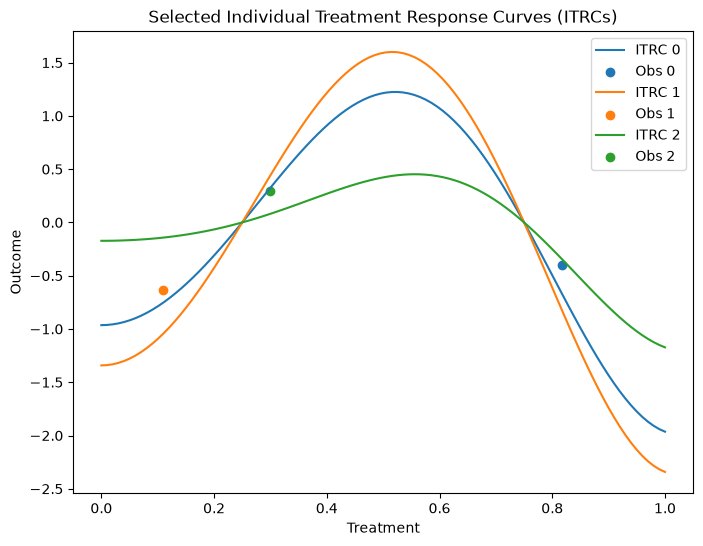

In [3]:
# Visualize synthetic data
fig = plt.figure(figsize=(8, 6))

t_grid = np.linspace(0, 1.0, 100)
ids = rng.choice(range(len(df)), 3)

for i, j in enumerate(ids):
    # Plot treatment-response curves
    plt.plot(t_grid, admit.dose_response(df.iloc[i], t_grid), label=f"ITRC {i}")
    # Plot "observed" treatment/outcomes
    plt.scatter(df.iloc[i]["t_obs"], df.iloc[i]["y_obs"], label=f"Obs {i}")

plt.xlabel("Treatment")
plt.ylabel("Outcome")
plt.title("Selected Individual Treatment Response Curves (ITRCs)")
plt.legend()
plt.show()

## CEPO Estimation

In [4]:
# Fit CCPFN estimator
estimator = CEPOEstimator(device=device)
estimator.fit(
    X=covariates.to_numpy(dtype=float),
    t=t_obs.to_numpy(dtype=float),
    y=y_obs.to_numpy(dtype=float),
)

In [5]:
# Generate example query individuals and counterfactual treatments. Query individuals
# do not have to be the same as context individuals.
N = 1_000
X_query = rng.uniform(0.0, 1.0, size=(N, 6))
t_query = rng.uniform(0.0, 1.0, size=N)

In [ ]:
# Predict CEPO
cepo_pred = estimator.estimate_cepo(X=X_query, t=t_query)

## Dose Response Visualization

Visualize the dose-response curves of one of the example individuals by passing the full treatment range to CCPFN.

In [7]:
# Setup
idx = 1  # Individual to test (between 0 and N - 1)
t_grid = np.linspace(0.0, 1.0, 100)  # Treatment grid
X = np.tile(X_query[idx], (100, 1))

# Predict
cepo_preds = estimator.estimate_cepo(X=X, t=t_grid)

# Ground truth ITRC
df_X = pd.DataFrame(X, columns=[f"x_{i}" for i in range(6)])
cepo_true = admit.dose_response(df_X, t_grid)

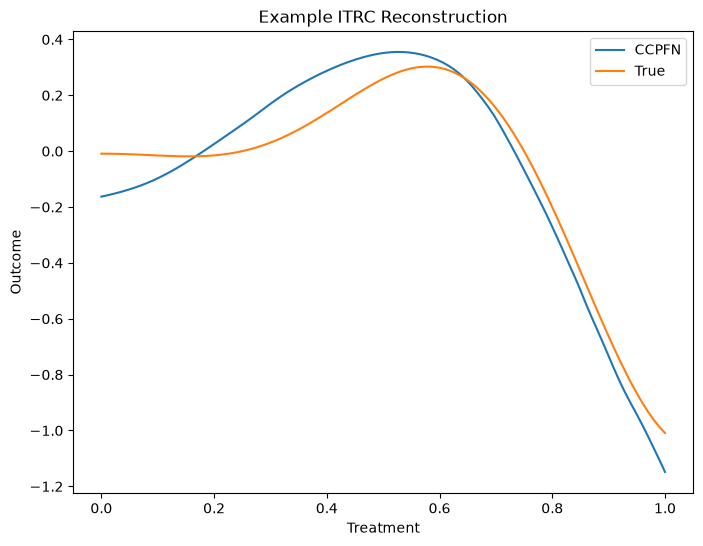

In [8]:
# Plot
fig = plt.figure(figsize=(8, 6))

plt.plot(t_grid, cepo_preds, label="CCPFN")
plt.plot(t_grid, cepo_true, label="True")

plt.xlabel("Treatment")
plt.ylabel("Outcome")
plt.title("Example ITRC Reconstruction")
plt.legend()
plt.show()